In [1]:
import os
import json
import copy
import time
from glob import glob
import numpy as np
import pandas as pd
import scipy
from scipy.stats import spearmanr, pearsonr
import qtl.plot

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
plt.rcParams.update({'font.family':'Helvetica', 
                     'svg.fonttype':'none',
                     'pdf.fonttype':42, 
                     'font.size':12})

In [2]:
cell_type_counts_fn = "data/combined_obs_cell_type_counts.tsv"
out_figure_dir = 'figures/'

In [3]:
cell_type_counts = pd.read_csv(cell_type_counts_fn, sep='\t')
cell_type_counts['label'] = cell_type_counts['predicted.id'] + ' (N=' + cell_type_counts['count'].astype(str) + ')'
cell_type_counts = cell_type_counts.set_index("predicted.id")
cell_type_counts

,count,label
predicted.id,,
CD14_Mono,767874,CD14_Mono (N=767874)
CD4_TCM,543523,CD4_TCM (N=543523)
CD4_Naive,457715,CD4_Naive (N=457715)
NK,432705,NK (N=432705)
CD8_TEM,357483,CD8_TEM (N=357483)
CD16_Mono,180128,CD16_Mono (N=180128)
B_naive,152441,B_naive (N=152441)
B_intermediate,114963,B_intermediate (N=114963)
CD4_CTL,105062,CD4_CTL (N=105062)


In [4]:
missing_models = ['ILC', 'CD8_Proliferating']
missing_scores = ['CD8_Proliferating', 'ILC']
exclude_celltypes = ['CD8_Proliferating', 'ILC', 'CD4_Proliferating']

In [5]:
frag_suffix = '_full'
outdir_suffix=f'chrombpnet_model{frag_suffix}_bias_NKFull1'
metrics = []
corrected = []
for cell_type in cell_type_counts.index:
    for fold in range(0, 5):
        result_dir = f"scATAC_ChromBPNet_models/{cell_type}/{outdir_suffix}_fold{fold}/"
        metric_fn = os.path.join(result_dir, "evaluation/chrombpnet_metrics.json")
        bias_metric_fn = os.path.join(result_dir, "evaluation/bias_metrics.json")
        bias_response_fn = os.path.join(result_dir, "evaluation/chrombpnet_nobias_max_bias_response.txt")
        if os.path.exists(metric_fn):
            with open(metric_fn) as fh:
                metric = json.load(fh)
            metric = pd.json_normalize(metric, sep='_')
            metric['model'] = 'chrombpnet\nbias-factorized'
            metric['cell_type'] = cell_type
            metrics.append(metric)
        if os.path.exists(bias_metric_fn):
            with open(bias_metric_fn) as fh:
                metric = json.load(fh)
            metric = pd.json_normalize(metric, sep='_')
            metric['model'] = 'bias'
            metric['cell_type'] = cell_type
            metrics.append(metric)
        if os.path.exists(bias_response_fn):
            with open(bias_response_fn) as fh:
                content = fh.read()
                is_corrected = content.split("_")[0]
                corrected.append({'cell_type': cell_type, 'fold': fold, 'is_corrected': is_corrected})
    
perf = pd.concat(metrics)
cols = np.concatenate([perf.columns[-2:], perf.columns[:-2]])
perf = perf[cols].reset_index(drop=True)
corrected = pd.DataFrame(corrected)

In [6]:
perf.to_csv('data/ChromBPNet_model_performance.csv')

/scratch/210789.1.whole/ipykernel_8896/481700799.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(order['label'].values)


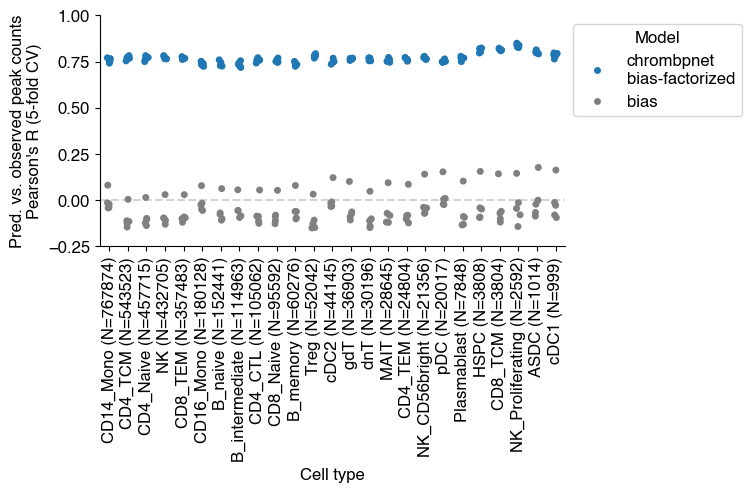

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


In [7]:
counts = perf['cell_type'].value_counts()
val_cell_types = counts[counts == 10].index
order = cell_type_counts[~cell_type_counts.index.isin(exclude_celltypes)]

fig, ax = plt.subplots(figsize=(6, 3))
sns.stripplot(x='cell_type', y='counts_metrics_peaks_pearsonr',
              hue='model', palette=['tab:blue', 'grey'],
              data=perf[perf['cell_type'].isin(val_cell_types)],
              order=order.index)
plt.xticks(rotation=90)
ax.spines[['top', 'right']].set_visible(False)
#ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.2), ncols=2, title='model')
ax.legend(bbox_to_anchor=(1, 1), title='Model')
ax.set_ylim(-0.25, 1)
ax.set_xticklabels(order['label'].values)
ax.set_xlabel('Cell type')
ax.set_ylabel("Pred. vs. observed peak counts\nPearson's R (5-fold CV)")
ax.axhline(0, ls='--', color='lightgrey')
plt.show()

ax.get_figure().savefig(os.path.join(out_figure_dir, "TenK10K_cell_type_specific_chromBPNet_model_performance.pdf"),
                        dpi=300, bbox_inches='tight')